Regressions

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import networkx as nx

Open hindcast data

In [2]:
PATH = '/climca/people/glattus/Hindcast_data_ready'

def df_xr_prep(df):
    da=df.to_xarray()
    da=da.rename({'index':'year'})
    return da

##La Plata
#SON
hind_SON_LaPlata_xr=xr.open_dataset(PATH+'/Target_vars_LP_SON.nc')

#DJF
hind_DJF_LaPlata_xr=xr.open_dataset(PATH+'/Target_vars_LP_DJF.nc')

##Andes
hind_SON_Andes_xr=xr.open_dataset(PATH+'/Target_vars_Andes_SON.nc')
hind_DJF_Andes_xr=xr.open_dataset(PATH+'/Target_vars_Andes_DJF.nc')

In [3]:
hind_SON_Andes_xr

<xarray.Dataset> Size: 2MB
Dimensions:                  (sample: 34272)
Coordinates:
    lead_block               <U9 36B ...
    init_month               (sample) int64 274kB ...
    season                   (sample) <U3 411kB ...
    forecast_reference_time  (sample) datetime64[ns] 274kB ...
    number                   (sample) int64 274kB ...
Dimensions without coordinates: sample
Data variables:
    t2m                      (sample) float64 274kB ...
    tp                       (sample) float64 274kB ...

Open drivers data

In [69]:
#spring
ocean_SON_xr=xr.open_dataset(PATH+'/ENSO_IOD_SON.nc').drop_vars('lead_block')
SAM_SON_xr=xr.open_dataset(PATH+'/SAM_ready_SON.nc')
SPV_SON_xr=xr.open_dataset(PATH+'/SPV_SON.nc').drop_vars('lead_block')


ocean_DJF_xr=xr.open_dataset(PATH+'/ENSO_IOB_DJF.nc').drop_vars('lead_block')
SAM_DJF_xr=xr.open_dataset(PATH+'/SAM_ready_DJF.nc')
VB_DJF_xr=xr.open_dataset(PATH+'/VB_DOY_combined.nc')

display(VB_DJF_xr)
display(SAM_DJF_xr)
display(ocean_DJF_xr)

<xarray.Dataset> Size: 137kB
Dimensions:                  (sample: 4284)
Coordinates:
    init_month               (sample) int64 34kB ...
    forecast_reference_time  (sample) datetime64[ns] 34kB ...
    number                   (sample) int64 34kB ...
Dimensions without coordinates: sample
Data variables:
    VB_DOY                   (sample) float64 34kB ...

<xarray.Dataset> Size: 2MB
Dimensions:                  (sample: 33864)
Coordinates:
    init_month               (sample) int64 271kB ...
    season                   (sample) <U3 406kB ...
    forecast_reference_time  (sample) datetime64[ns] 271kB ...
    number                   (sample) int64 271kB ...
Dimensions without coordinates: sample
Data variables:
    S_SAM                    (sample) float32 135kB ...
    A_SAM                    (sample) float64 271kB ...

<xarray.Dataset> Size: 2MB
Dimensions:                  (sample: 33864)
Coordinates:
    init_month               (sample) int64 271kB ...
    season                   (sample) <U3 406kB ...
    forecast_reference_time  (sample) datetime64[ns] 271kB ...
    number                   (sample) int64 271kB ...
Dimensions without coordinates: sample
Data variables:
    IOBW                     (sample) float64 271kB ...
    nino34                   (sample) float64 271kB ...

In [5]:
def align_hindcast_arrays(
    array_list,
    names=None,
    sample_coords=None,
    reference=0,
    verbose=True
):
    """
    Check and align xarray Datasets/DataArrays containing hindcast samples.

    Samples are identified by a combination of coordinates, by default:

        number
        init_month
        season
        forecast_reference_time

    The function:
      1. checks dimensions and required coordinates
      2. checks coordinate equality
      3. checks whether all datasets contain the same sample identities
      4. detects ordering differences
      5. reorders all datasets to the reference dataset's sample order
      6. verifies the final alignment

    Parameters
    ----------
    array_list : list
        List of xarray Dataset/DataArray objects.

    names : list, optional
        Names for diagnostic output.

    sample_coords : list, optional
        Coordinates defining a unique hindcast sample.

    reference : int
        Index of the dataset whose sample ordering is used
        as the reference.

    verbose : bool
        Print diagnostics.

    Returns
    -------
    aligned_arrays : list
        Aligned xarray objects.
    """

    # ---------------------------------------------------------
    # 1. Defaults
    # ---------------------------------------------------------

    if sample_coords is None:
        sample_coords = [
            "number",
            "init_month",
            "season",
            "forecast_reference_time"
        ]

    n_arrays = len(array_list)

    if names is None:
        names = [
            f"array_{i}"
            for i in range(n_arrays)
        ]

    if len(names) != n_arrays:
        raise ValueError(
            "names must have the same length as array_list"
        )

    if reference < 0 or reference >= n_arrays:
        raise ValueError(
            "reference must be a valid array index"
        )

    # ---------------------------------------------------------
    # 2. Basic checks
    # ---------------------------------------------------------

    if verbose:
        print("=" * 70)
        print("BASIC STRUCTURE")
        print("=" * 70)

    for name, arr in zip(names, array_list):

        if not isinstance(
            arr,
            (xr.Dataset, xr.DataArray)
        ):
            raise TypeError(
                f"{name} is not an xarray Dataset/DataArray"
            )

        if "sample" not in arr.dims:
            raise ValueError(
                f"{name} does not contain a 'sample' dimension"
            )

        print(
            f"{name:15s} "
            f"sample size = {arr.sizes['sample']}"
        )

    # ---------------------------------------------------------
    # 3. Check sample sizes
    # ---------------------------------------------------------

    sample_sizes = [
        arr.sizes["sample"]
        for arr in array_list
    ]

    if len(set(sample_sizes)) != 1:

        raise ValueError(
            "Datasets have different sample sizes:\n"
            + "\n".join(
                f"{name}: {size}"
                for name, size in zip(
                    names,
                    sample_sizes
                )
            )
        )

    n_samples = sample_sizes[0]

    # ---------------------------------------------------------
    # 4. Check sample coordinates
    # ---------------------------------------------------------

    if verbose:
        print("\n" + "=" * 70)
        print("CHECKING SAMPLE COORDINATES")
        print("=" * 70)

    for name, arr in zip(names, array_list):

        for coord in sample_coords:

            if coord not in arr.coords:

                raise ValueError(
                    f"{name} is missing coordinate "
                    f"{coord!r}"
                )

            if arr[coord].dims != ("sample",):

                raise ValueError(
                    f"{name}[{coord!r}] has dimensions "
                    f"{arr[coord].dims}, expected ('sample',)"
                )

        print(
            f"{name:15s}: all coordinates present"
        )

    # ---------------------------------------------------------
    # 5. Construct sample identities
    # ---------------------------------------------------------

    if verbose:
        print("\n" + "=" * 70)
        print("CONSTRUCTING SAMPLE IDENTITIES")
        print("=" * 70)

    identities = []

    for name, arr in zip(names, array_list):

        identity = pd.MultiIndex.from_arrays(
            [
                arr[coord].values
                for coord in sample_coords
            ],
            names=sample_coords
        )

        identities.append(identity)

        n_unique = identity.nunique()

        print(
            f"{name:15s}: "
            f"{n_unique} unique / "
            f"{n_samples} total"
        )

        if identity.has_duplicates:

            raise ValueError(
                f"{name} contains duplicate "
                f"sample identities."
            )

    # ---------------------------------------------------------
    # 6. Compare coordinate arrays position-by-position
    # ---------------------------------------------------------

    if verbose:
        print("\n" + "=" * 70)
        print("POSITIONAL COMPARISON")
        print("=" * 70)

    ref_arr = array_list[reference]
    ref_name = names[reference]

    for coord in sample_coords:

        print(f"\n{coord}")

        for i, arr in enumerate(array_list):

            if i == reference:
                continue

            same = np.array_equal(
                ref_arr[coord].values,
                arr[coord].values
            )

            print(
                f"  {ref_name} == {names[i]}: {same}"
            )

    # ---------------------------------------------------------
    # 7. Compare sample sets
    # ---------------------------------------------------------

    if verbose:
        print("\n" + "=" * 70)
        print("SAMPLE SET COMPARISON")
        print("=" * 70)

    reference_identity = identities[reference]

    reference_set = set(reference_identity)

    for i, identity in enumerate(identities):

        if i == reference:
            continue

        current_set = set(identity)

        only_reference = (
            reference_set - current_set
        )

        only_current = (
            current_set - reference_set
        )

        same_set = (
            len(only_reference) == 0
            and len(only_current) == 0
        )

        print(
            f"\n{ref_name} vs {names[i]}"
        )

        print(
            f"Same sample set: {same_set}"
        )

        print(
            f"Only {ref_name}: "
            f"{len(only_reference)}"
        )

        print(
            f"Only {names[i]}: "
            f"{len(only_current)}"
        )

        if not same_set:

            print("\nExample samples only in reference:")

            for item in list(only_reference)[:5]:
                print(item)

            print(
                "\nExample samples only in current:"
            )

            for item in list(only_current)[:5]:
                print(item)

            raise ValueError(
                f"{names[i]} does not contain "
                f"the same hindcast samples as "
                f"{ref_name}."
            )

    print(
        "\nAll datasets contain exactly the "
        "same sample identities."
    )

    # ---------------------------------------------------------
    # 8. Reorder datasets to reference ordering
    # ---------------------------------------------------------

    if verbose:
        print("\n" + "=" * 70)
        print("REORDERING TO REFERENCE SAMPLE ORDER")
        print("=" * 70)

    aligned_arrays = []

    for i, (name, arr, identity) in enumerate(
        zip(names, array_list, identities)
    ):

        # -----------------------------------------------------
        # Find the position of every reference sample
        # in this dataset.
        # -----------------------------------------------------

        position_lookup = {
            sample_identity: position
            for position, sample_identity
            in enumerate(identity)
        }

        try:

            reorder_index = np.array(
                [
                    position_lookup[sample_identity]
                    for sample_identity
                    in reference_identity
                ],
                dtype=int
            )

        except KeyError as e:

            raise ValueError(
                f"Could not find sample {e} "
                f"in {name}"
            )

        # Reorder along original sample dimension
        arr_aligned = arr.isel(
            sample=reorder_index
        )

        aligned_arrays.append(
            arr_aligned
        )

        # Check that ordering now matches
        new_identity = pd.MultiIndex.from_arrays(
            [
                arr_aligned[coord].values
                for coord in sample_coords
            ],
            names=sample_coords
        )

        if not new_identity.equals(
            reference_identity
        ):

            raise RuntimeError(
                f"Reordering failed for {name}"
            )

        print(
            f"{name:15s}: reordered successfully"
        )

    # ---------------------------------------------------------
    # 9. Final verification
    # ---------------------------------------------------------

    if verbose:
        print("\n" + "=" * 70)
        print("FINAL VERIFICATION")
        print("=" * 70)

    for coord in sample_coords:

        reference_values = (
            aligned_arrays[reference][coord].values
        )

        for i, arr in enumerate(aligned_arrays):

            same = np.array_equal(
                reference_values,
                arr[coord].values
            )

            if not same:

                raise RuntimeError(
                    f"Final alignment failed for "
                    f"{names[i]} coordinate {coord}"
                )

    print(
        "All sample-identifying coordinates "
        "are now identical."
    )

    print(
        f"All arrays contain {n_samples} "
        "aligned samples."
    )

    print("\nAlignment successful.")

    return aligned_arrays

In [6]:
all_aligned=align_hindcast_arrays([hind_SON_LaPlata_xr, hind_SON_Andes_xr,ocean_SON_xr, SPV_SON_xr, SAM_SON_xr], 
                                  names=['LaPlata','Andes','ocean', 'SPV', 'SAM'])
target_Andes_SON_xr=all_aligned[1]
target_LP_SON_xr=all_aligned[0]
drivers_aligned=all_aligned[2:]
drivers_SON_xr=xr.merge(drivers_aligned)

BASIC STRUCTURE
LaPlata         sample size = 34272
Andes           sample size = 34272
ocean           sample size = 34272
SPV             sample size = 34272
SAM             sample size = 34272

CHECKING SAMPLE COORDINATES
LaPlata        : all coordinates present
Andes          : all coordinates present
ocean          : all coordinates present
SPV            : all coordinates present
SAM            : all coordinates present

CONSTRUCTING SAMPLE IDENTITIES
LaPlata        : 34272 unique / 34272 total
Andes          : 34272 unique / 34272 total
ocean          : 34272 unique / 34272 total
SPV            : 34272 unique / 34272 total
SAM            : 34272 unique / 34272 total

POSITIONAL COMPARISON

number
  LaPlata == Andes: True
  LaPlata == ocean: True
  LaPlata == SPV: True
  LaPlata == SAM: True

init_month
  LaPlata == Andes: True
  LaPlata == ocean: True
  LaPlata == SPV: False
  LaPlata == SAM: True

season
  LaPlata == Andes: True
  LaPlata == ocean: True
  LaPlata == SPV: True
 

In [7]:
drivers_SON_xr=drivers_SON_xr.rename_vars({'nino34':'ENSO', 'iod_index':'IOD', 'u':'SPV'})
display(drivers_SON_xr)
#summer
SAM_DJF_xr=xr.open_dataset(PATH+'/SAM_ready_DJF.nc')

<xarray.Dataset> Size: 2MB
Dimensions:                  (sample: 34272)
Coordinates:
    init_month               (sample) int64 274kB 6 6 6 6 6 6 6 ... 9 9 9 9 9 9
    season                   (sample) <U3 411kB 'SON' 'SON' ... 'SON' 'SON'
    forecast_reference_time  (sample) datetime64[ns] 274kB 1981-06-01 ... 202...
    number                   (sample) int64 274kB 0 1 2 3 4 5 ... 46 47 48 49 50
    pressure_level           float64 8B ...
Dimensions without coordinates: sample
Data variables:
    IOD                      (sample) float64 274kB ...
    ENSO                     (sample) float64 274kB ...
    SPV                      (sample) float64 274kB ...
    S_SAM                    (sample) float32 137kB ...
    A_SAM                    (sample) float64 274kB ...

## Start regression part

In [8]:
import sys
sys.path.insert(0, "../whole_period_effects")  # add Folder_2 path to search list

import Functions

In [9]:
drivers_SON= ['ENSO', 'IOD', 'SPV', 'S_SAM', 'A_SAM']
drivers_tot_SON=['ENSO', 'IOD', 'SPV']

In [80]:
def bootstrap_regression(
    target_ds,
    driver_ds,
    target_var,
    driver_vars,
    n_boot=50,
    sample_size=73,
    add_intercept=True,
    printer=False,
    seed=42,
    quantiles=None
):
    """
    target_var: string, e.g. "tprate" or "t2m"
    driver_vars: list of strings, e.g. ["nino34"] or ["nino34", "iod_index"]
    """
    #rerun yields the same result from now on
    rng = np.random.default_rng(seed)

    results = []

    n_samples = target_ds.sizes["sample"]

    # Check that target and drivers have same number of samples
    for var in driver_vars:
        if driver_ds.sizes["sample"] != n_samples:
            raise ValueError(
                f"Target and driver sample sizes differ: "
                f"target={n_samples}, {var}={driver_ds.sizes['sample']}"
            )
        
    #initalize counter on how many bootstraps have enough values
    counter=0
    for i in range(n_boot):

        
        idx = rng.choice(n_samples, size=sample_size, replace=True)

        y = target_ds[target_var].isel(sample=idx).values

        X = pd.DataFrame({
            var: driver_ds[var].isel(sample=idx).values
            for var in driver_vars
        })

        df = X.copy()
        df["target"] = y
        df = df.dropna()

        # Number of valid observations
        n_valid = len(df)

        # Not enough data to fit regression
        if n_valid == 0:
            print(f"Bootstrap {i}: 0 valid samples -- skipping")
            continue

        # Need at least more observations than parameters
        n_predictors = len(driver_vars)
        n_parameters = n_predictors + int(add_intercept)

        if n_valid <= n_parameters:
            if printer:
                print(
                f"Bootstrap {i}: only {n_valid} valid samples "
                f"for {n_parameters} parameters -- skipping"
                )
            else:
                counter+=1
            continue

        X_clean = df[driver_vars]
        y_clean = df["target"]

        if add_intercept:
            X_clean = sm.add_constant(X_clean)

    
        
        if quantiles is None:
            model = sm.OLS(y_clean, X_clean).fit()

            row = {
                                "bootstrap": i,
                                "target": target_var,
                                "drivers": "+".join(driver_vars),
                                "r2": model.rsquared
                            }
            
            for name, value in model.params.items():
                        row[f"coef_{name}"] = value

        else:
            #quantiles = [0.05, 0.5, 0.95]
            
            for quantile in quantiles:
                qr = QuantileRegressor(quantile=quantile, fit_intercept=add_intercept, alpha=0)
                model = qr.fit(X, y_clean)

                row = {
                                    "bootstrap": i,
                                    "target": target_var,
                                    "drivers": "+".join(driver_vars),
                                    f"r2_{quantile}": model.rsquared
                                }
                
                # Pairs column names directly with their respective slope
                for col_name, coef_val in zip(X.columns, model.coef_):
                    row[f'coef_{col_name}_{quantile}'] = coef_val
                    
                if add_intercept:
                    row[f'intercept_{quantile}'] = model.intercept_

    
        

        results.append(row)
    if ~printer:
        print('Valid bootstraps: '+ str(n_boot-counter)+'/'+str(n_boot))
    return pd.DataFrame(results)



In [78]:
from sklearn.linear_model import QuantileRegressor

In [ ]:
##LP
#SON
results_direct_precip_LP_SON = bootstrap_regression(
    target_ds=target_LP_SON_xr,
    driver_ds=drivers_SON_xr,
    target_var="tp",
    driver_vars=drivers_SON,
    n_boot=200,
    add_intercept=False
    sample_size=73
)

results_direct_temp_LP_SON = bootstrap_regression(
    target_ds=target_LP_SON_xr,
    driver_ds=drivers_SON_xr,
    target_var="t2m",
    driver_vars=drivers_SON,
    n_boot=100,
    add_intercept=False
    sample_size=73
)

##Andes
#SON
results_direct_temp_Andes_SON = bootstrap_regression(
    target_ds=target_Andes_SON_xr,
    driver_ds=drivers_SON_xr,
    target_var="t2m",
    driver_vars=drivers_SON,
    n_boot=100,
    sample_size=73
)

results_direct_precip_Andes_SON = bootstrap_regression(
    target_ds=target_Andes_SON_xr,
    driver_ds=drivers_SON_xr,
    target_var="tp",
    driver_vars=drivers_SON,
    n_boot=100,
    sample_size=73
)

#DJF

Valid bootstraps: 157/200
Valid bootstraps: 81/100
Valid bootstraps: 81/100
Valid bootstraps: 81/100


In [71]:
def plot_bootstrap_coefficients(results, driver_vars, title="Bootstrap regression coefficients"):

    fsize=16
    ncols=len(driver_vars)

    fig, axes= plt.subplots(ncols=ncols, figsize=(ncols*6, 6), sharey=True)

    for i, var in enumerate(driver_vars):
        n, bins, _=axes[i].hist(
            results[f"coef_{var}"],
            bins=15,
            label=var
        )

    
        mean = results[f"coef_{var}"].mean()
        std = results[f"coef_{var}"].std()

        axes[i].axvline(
                    mean,
                    linestyle="--", color='red', 
                    label=f'Mean: {mean:.2f}'
                )

        axes[i].fill_betweenx(x1=mean-std, x2=mean+std, y=(0,max(n)), alpha=.3, color='red', label='$\pm 1 \sigma$')

        axes[i].set_xlabel(f"Regression coefficient of {var}", fontsize=fsize)
        #axes[i].set_title(f'{var}-->{target}')
        axes[i].tick_params( axis="both",
                    which="major",
                    labelsize=fsize)
        axes[i].grid(alpha=.3)
        axes[i].legend(fontsize=fsize)

    axes[0].set_ylabel("Count", fontsize=fsize)
    fig.suptitle(title, fontsize=fsize+4, fontweight='heavy')
    plt.show()

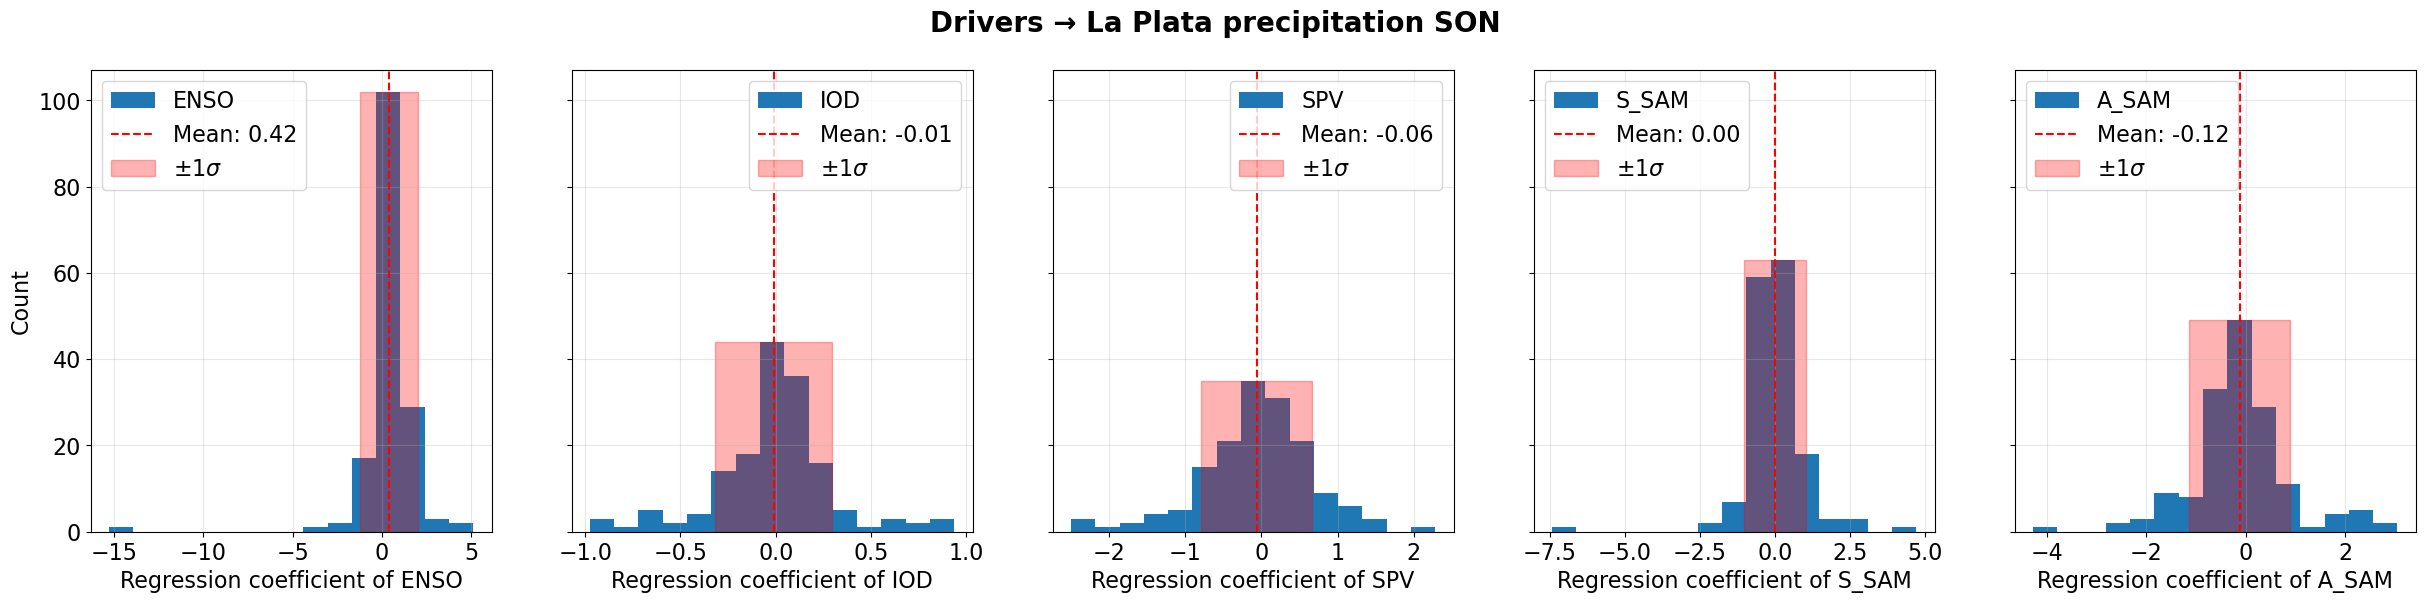

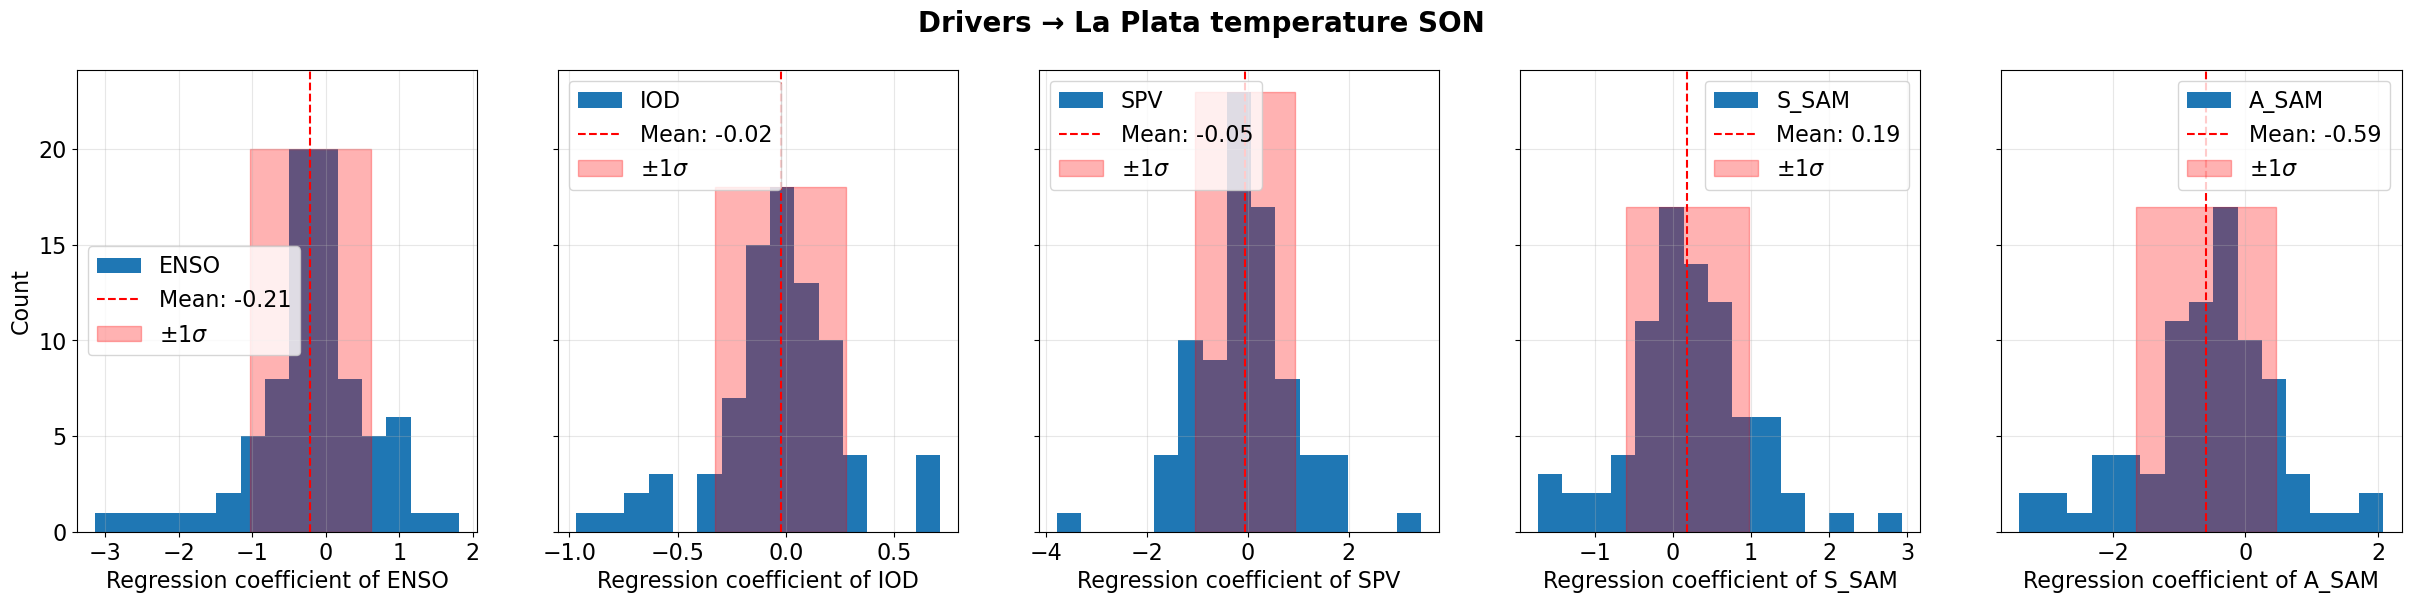

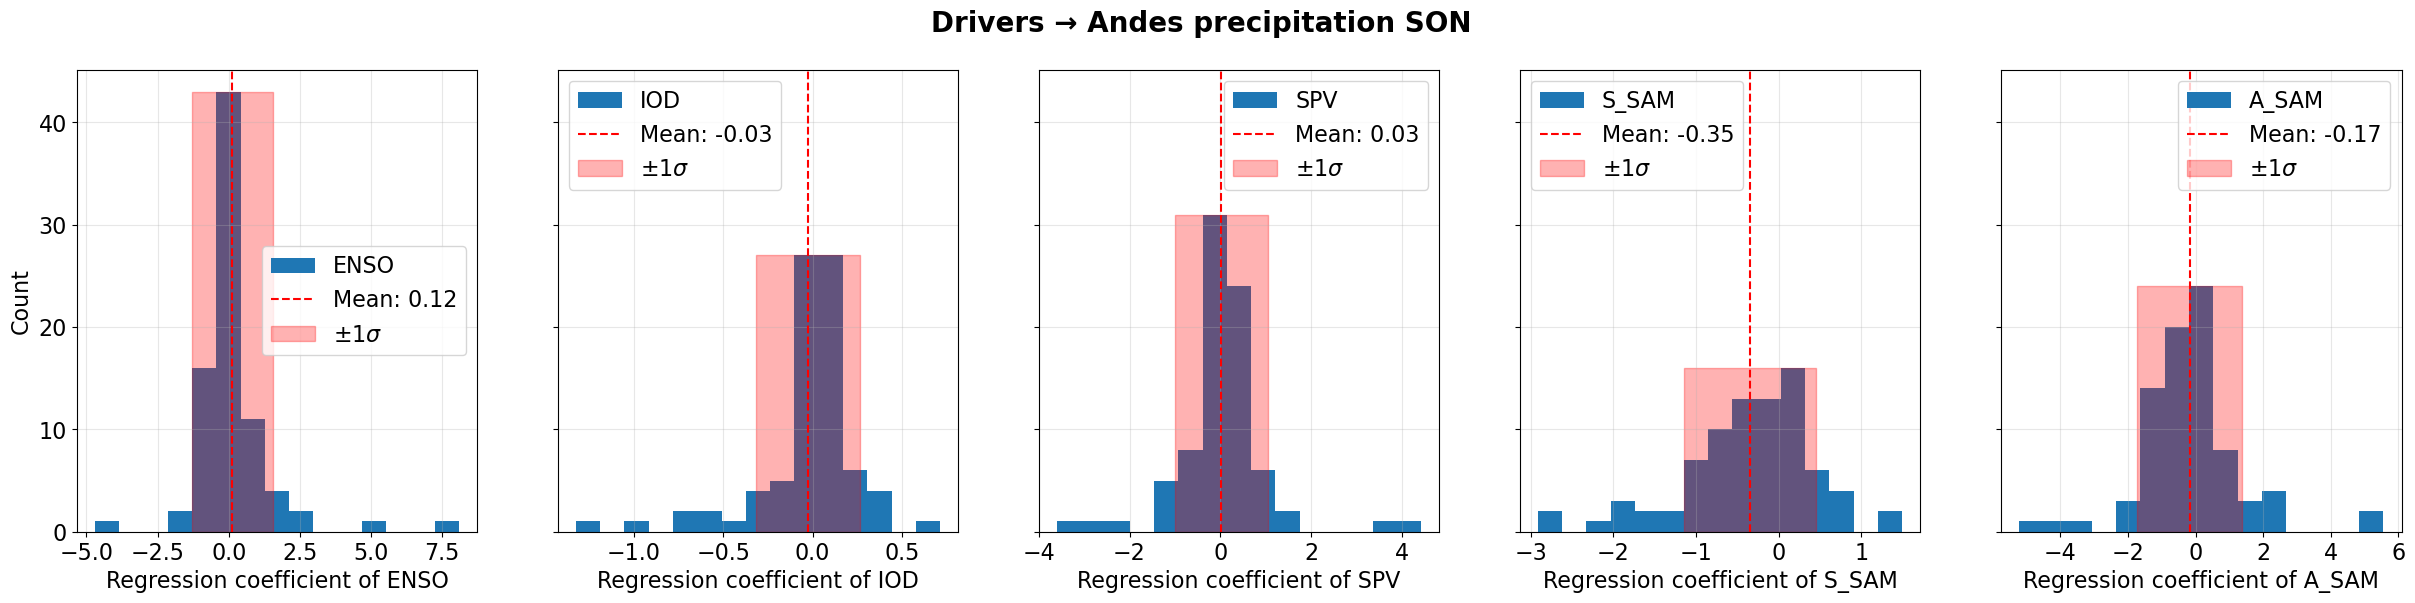

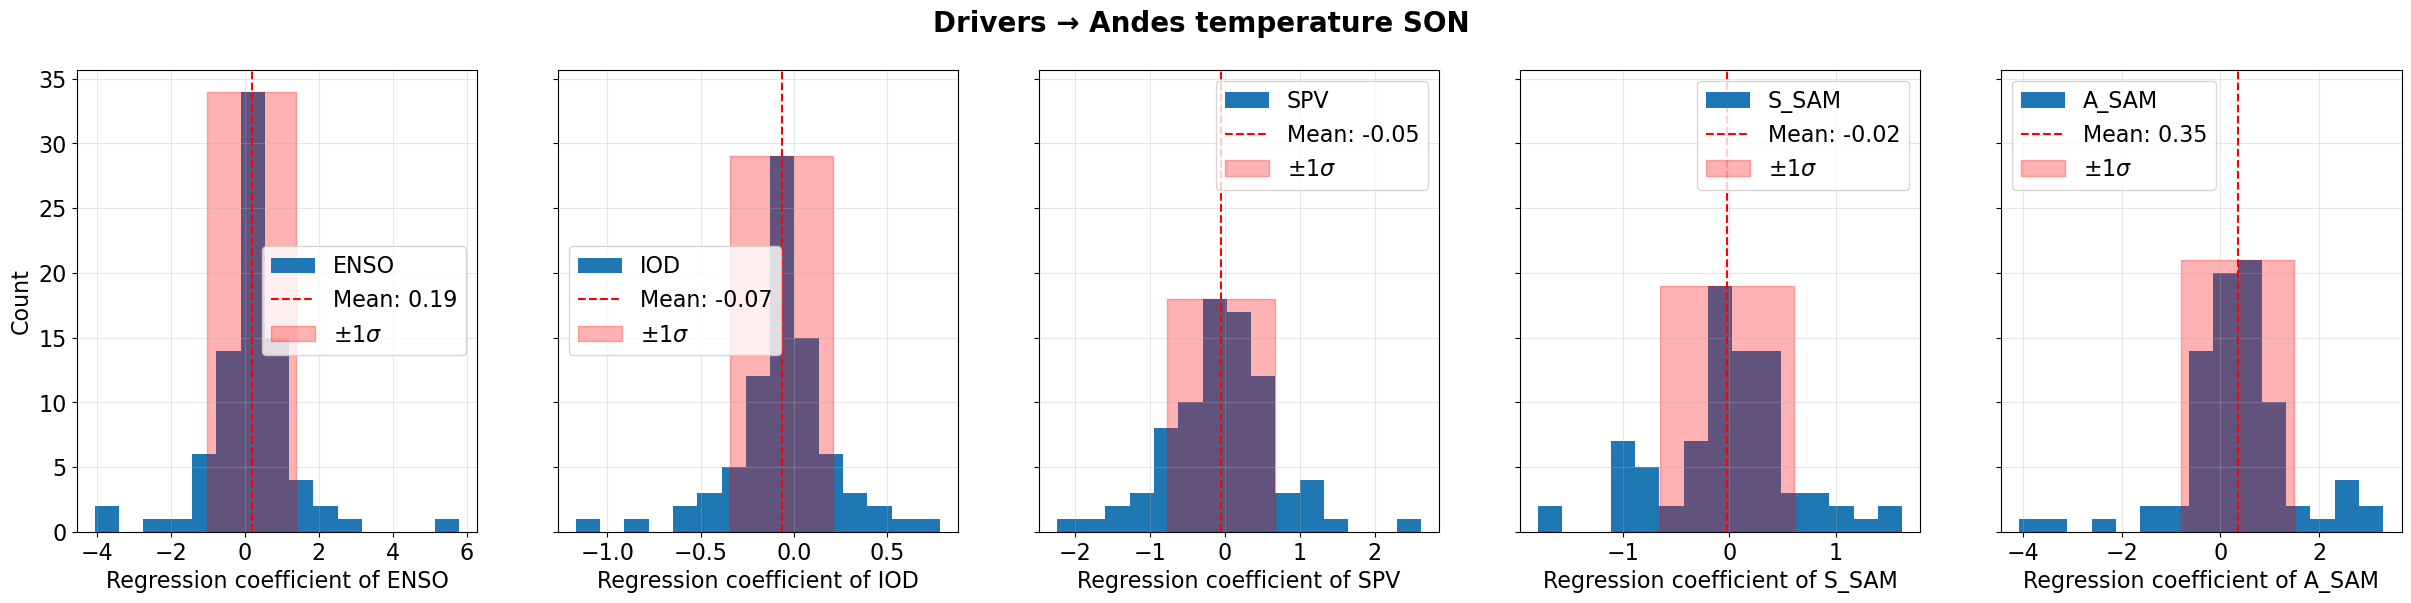

In [72]:
plot_bootstrap_coefficients(
    results_direct_precip_LP_SON,
    driver_vars=drivers_SON,
    title="Drivers → La Plata precipitation SON"
)

plot_bootstrap_coefficients(
    results_direct_temp_LP_SON,
    driver_vars=drivers_SON,
    title="Drivers → La Plata temperature SON"
)

plot_bootstrap_coefficients(
    results_direct_precip_Andes_SON,
    driver_vars=drivers_SON,
    title="Drivers → Andes precipitation SON"
)

plot_bootstrap_coefficients(
    results_direct_temp_Andes_SON,
    driver_vars=drivers_SON,
    title="Drivers → Andes temperature SON"
)

Try to find number of bootstraps where we find convergence

Valid bootstraps: 88/100
Valid bootstraps: 172/200
Valid bootstraps: 261/300
Valid bootstraps: 890/1000


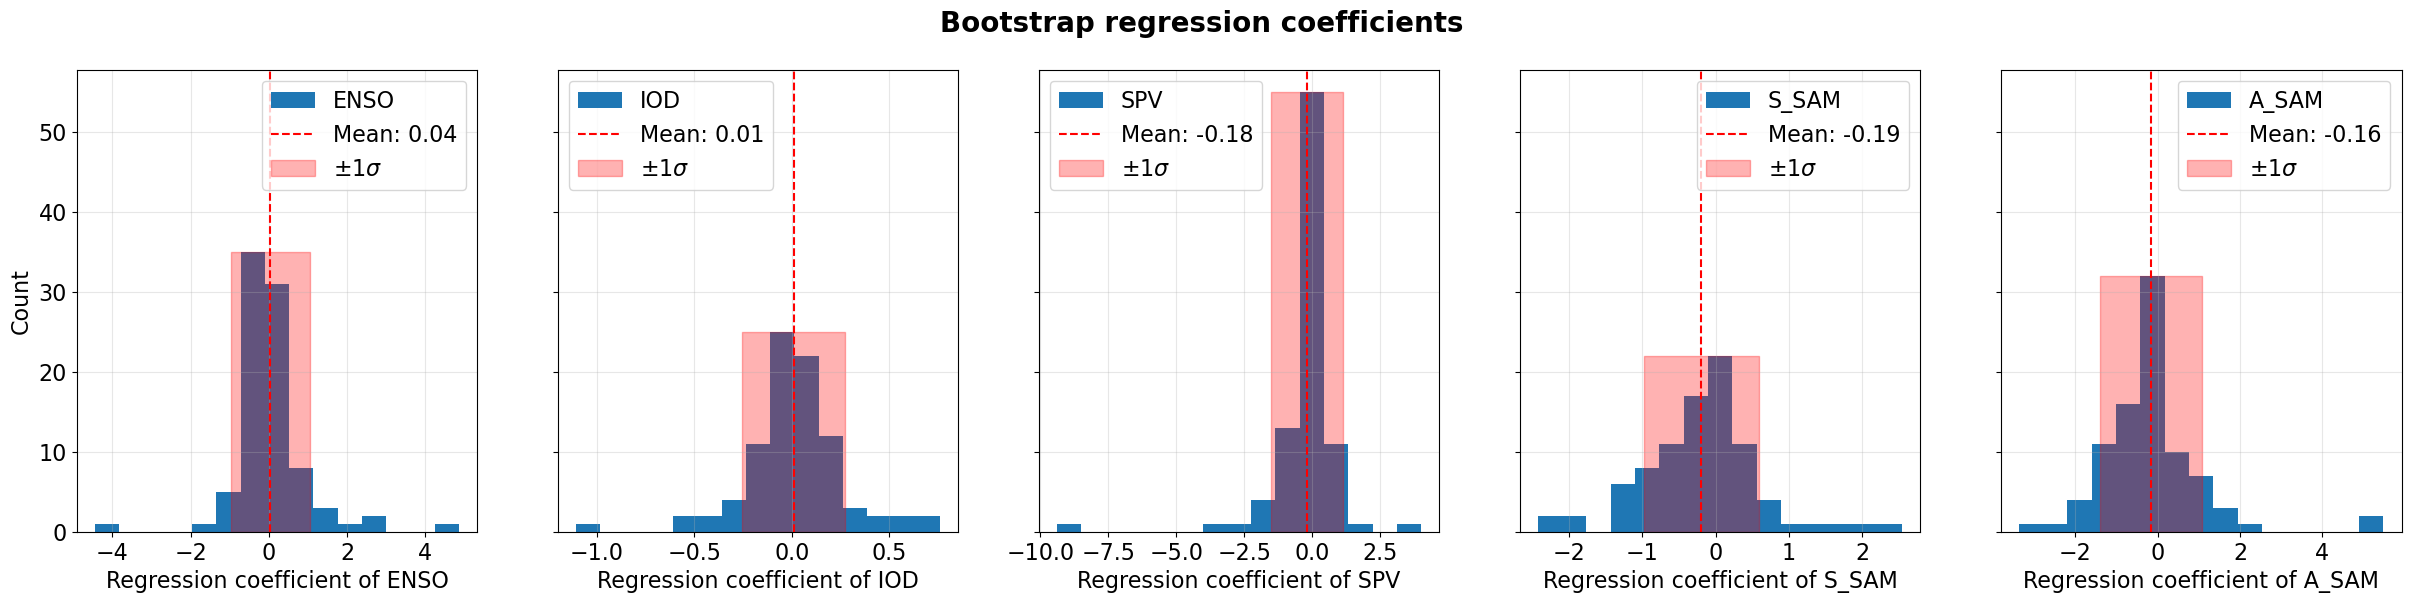

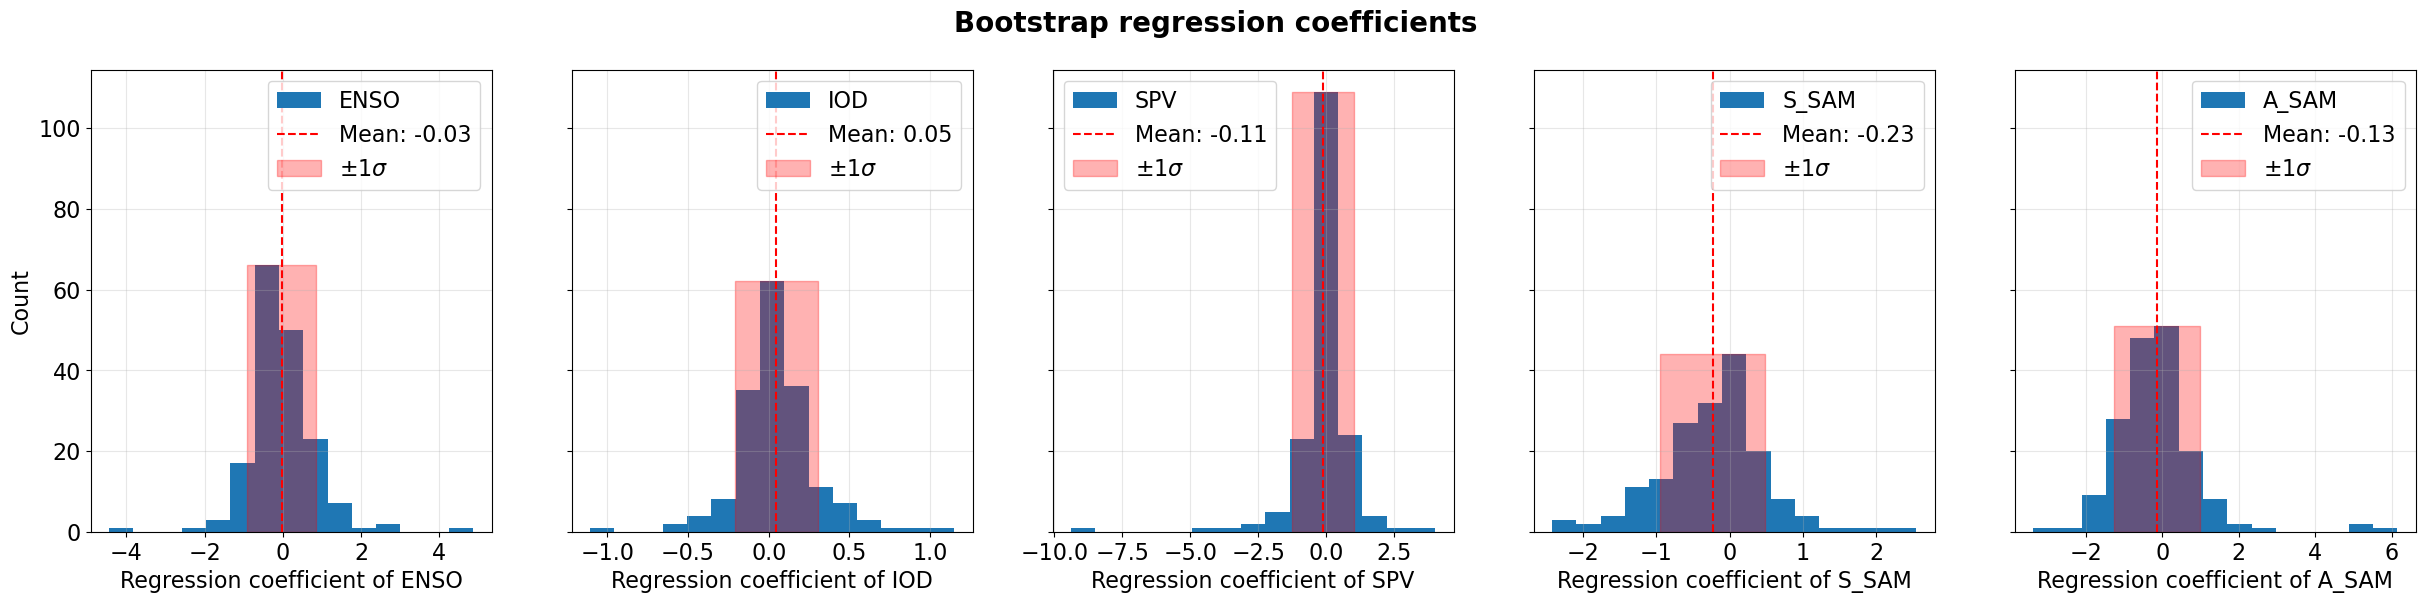

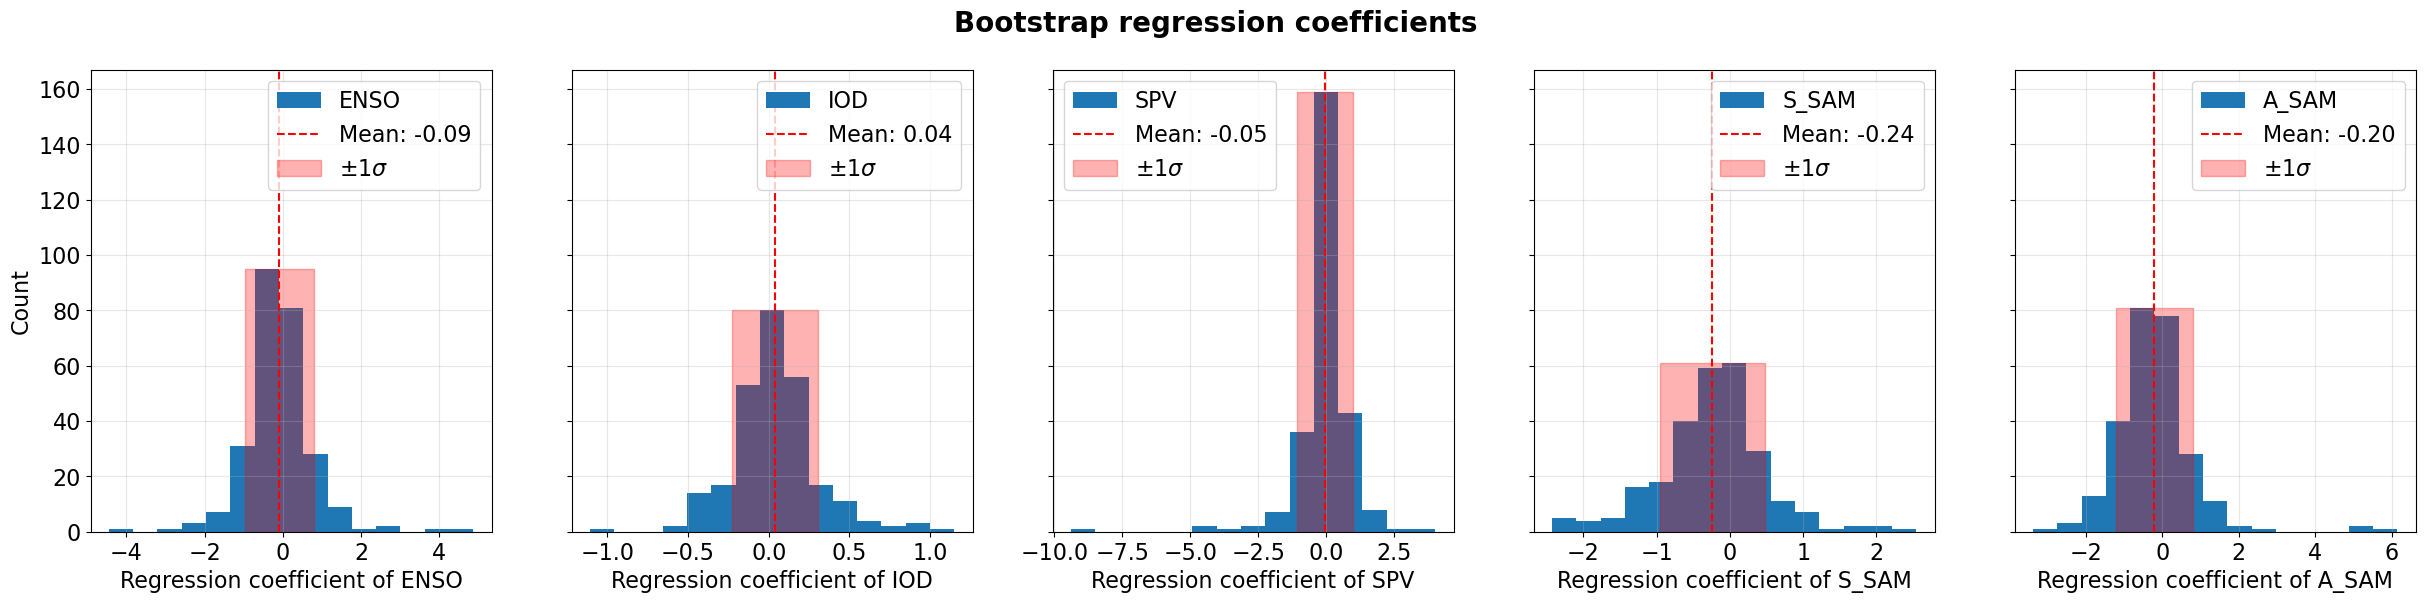

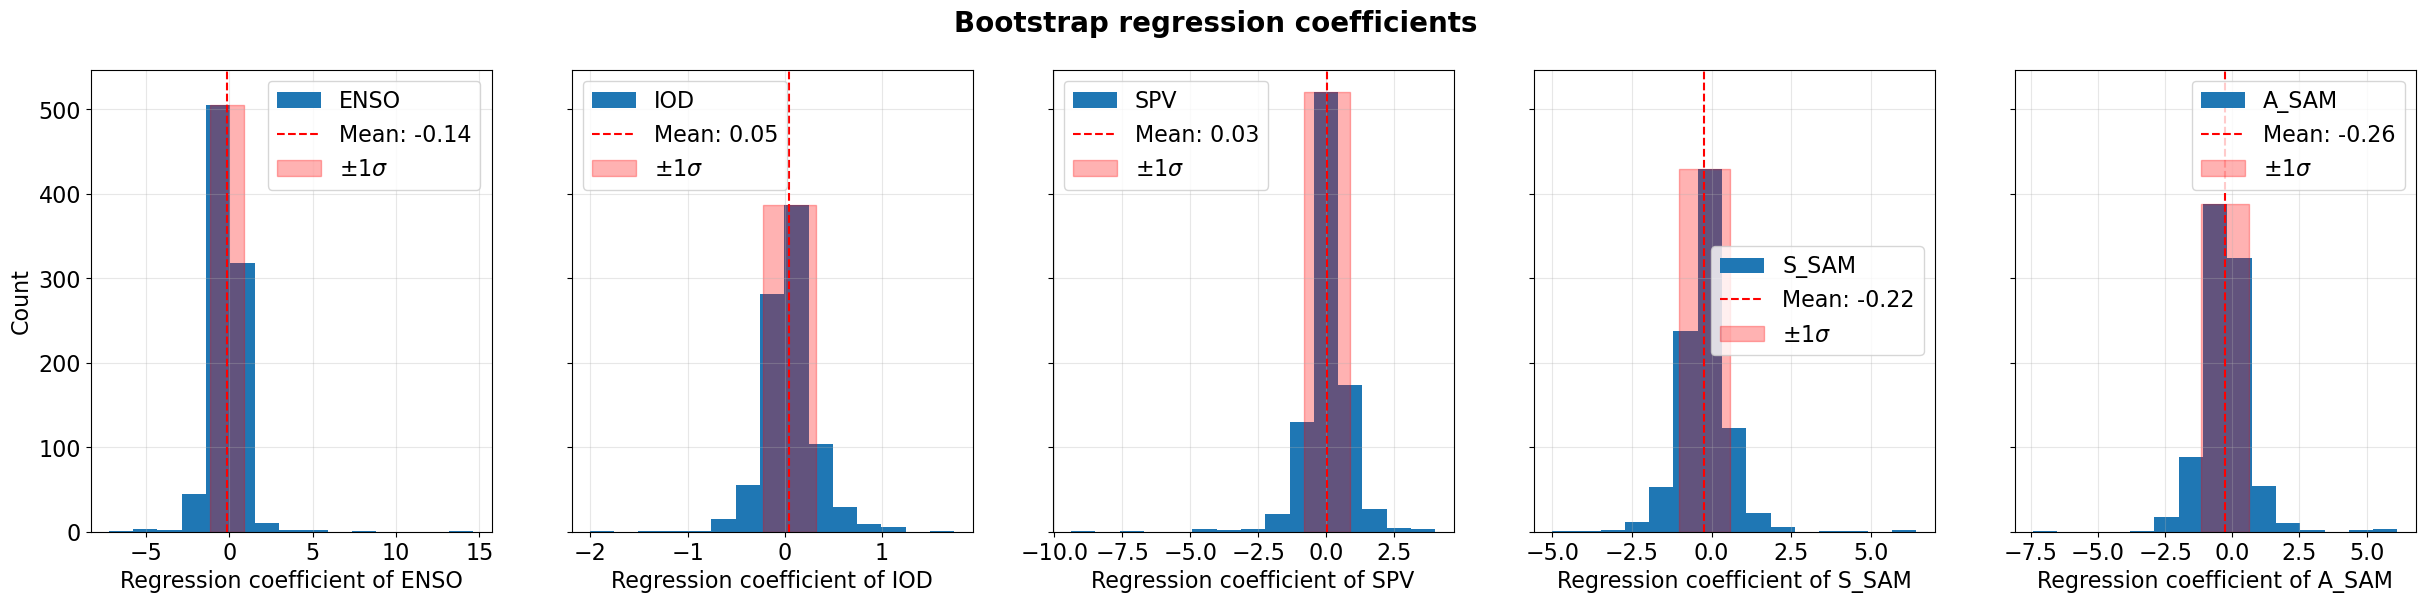

In [81]:
results_direct_precip_Andes_SON_100 = bootstrap_regression(
    target_ds=target_Andes_SON_xr,
    driver_ds=drivers_SON_xr,
    target_var="tp",
    driver_vars=drivers_SON,
    n_boot=100,
    add_intercept=False,
    sample_size=73
)

results_direct_precip_Andes_SON_200 = bootstrap_regression(
    target_ds=target_Andes_SON_xr,
    driver_ds=drivers_SON_xr,
    target_var="tp",
    driver_vars=drivers_SON,
    n_boot=200,
    add_intercept=False,
    sample_size=73
)

results_direct_precip_Andes_SON_300 = bootstrap_regression(
    target_ds=target_Andes_SON_xr,
    driver_ds=drivers_SON_xr,
    target_var="tp",
    driver_vars=drivers_SON,
    n_boot=300,
    add_intercept=False,
    sample_size=73
)

results_direct_precip_Andes_SON_1000 = bootstrap_regression(
    target_ds=target_Andes_SON_xr,
    driver_ds=drivers_SON_xr,
    target_var="tp",
    driver_vars=drivers_SON,
    n_boot=1000,
    add_intercept=False,
    sample_size=73
)

plot_bootstrap_coefficients(results_direct_precip_Andes_SON_100, drivers_SON)
plot_bootstrap_coefficients(results_direct_precip_Andes_SON_200, drivers_SON)
plot_bootstrap_coefficients(results_direct_precip_Andes_SON_300, drivers_SON)
plot_bootstrap_coefficients(results_direct_precip_Andes_SON_1000, drivers_SON)

In [84]:
def convergence_boot_plot(
    bootstrap_num,
    target_ds,
    drivers_ds,
    target_var,
    drivers_list,
    sample_size=73
):
    """
    Examine convergence of bootstrap regression coefficients.

    Parameters
    ----------
    bootstrap_num : array-like
        Numbers of bootstrap iterations to test, e.g.
        np.arange(20, 401, 20)

    target_ds : xarray.Dataset
        Target dataset.

    drivers_ds : xarray.Dataset
        Driver dataset.

    target_var : str
        Target variable.

    drivers_list : list
        Regression predictor names.

    sample_size : int
        Number of observations drawn in each bootstrap sample.
    """

    convergence = {
        driver: {
            "n_boot": [],
            "mean": [],
            "median": [],
            "std": [],
            "lower": [],
            "upper": [],
            "sign_fraction": []
        }
        for driver in drivers_list
    }

    for num in bootstrap_num:

        #print(f"Running {num} bootstrap samples...")

        results = bootstrap_regression(
            target_ds=target_ds,
            driver_ds=drivers_ds,
            target_var=target_var,
            driver_vars=drivers_list,
            n_boot=num,
            add_intercept=False,
            sample_size=sample_size
        )

        for driver in drivers_list:

            coef = results[f"coef_{driver}"].dropna()

            convergence[driver]["n_boot"].append(num)

            convergence[driver]["mean"].append(
                coef.mean()
            )

            convergence[driver]["median"].append(
                coef.median()
            )

            convergence[driver]["std"].append(
                coef.std()
            )

            convergence[driver]["sign_fraction"].append(
                np.mean(np.sign(coef) == np.sign(coef.mean()))
            )

    # ---------------------------------------------------------
    # Plot
    # ---------------------------------------------------------

    fig, axes = plt.subplots(
        ncols=len(drivers_list),
        figsize=(6 * len(drivers_list), 5),
        squeeze=False
    )

    axes = axes[0]

    for i, driver in enumerate(drivers_list):

        ax = axes[i]

        n = convergence[driver]["n_boot"]
        mean = convergence[driver]["mean"]
        std= convergence[driver]['std']
        
        # Mean coefficient
        ax.plot(
            n,
            mean,
            label="Mean coefficient"
        )

        # 1 std region
        #ax.fill_between(
        #    n,
        #    np.array(mean)-np.array(std),
        #    np.array(mean)+np.array(std),
        #    alpha=0.2,
        #    label="+-1 std"
        #)

        # Zero line
        #ax.axhline(
        #    0,
        #    linestyle="dotted",
        #    linewidth=1
        #)

        ax.set_title(driver)
        ax.set_xlabel("Number of bootstrap samples")
        ax.set_ylabel("Regression coefficient")

        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

    return convergence

Valid bootstraps: 88/100
Valid bootstraps: 131/150
Valid bootstraps: 172/200
Valid bootstraps: 215/250
Valid bootstraps: 261/300
Valid bootstraps: 306/350
Valid bootstraps: 346/400
Valid bootstraps: 390/450
Valid bootstraps: 432/500
Valid bootstraps: 470/550
Valid bootstraps: 518/600
Valid bootstraps: 563/650
Valid bootstraps: 610/700
Valid bootstraps: 656/750


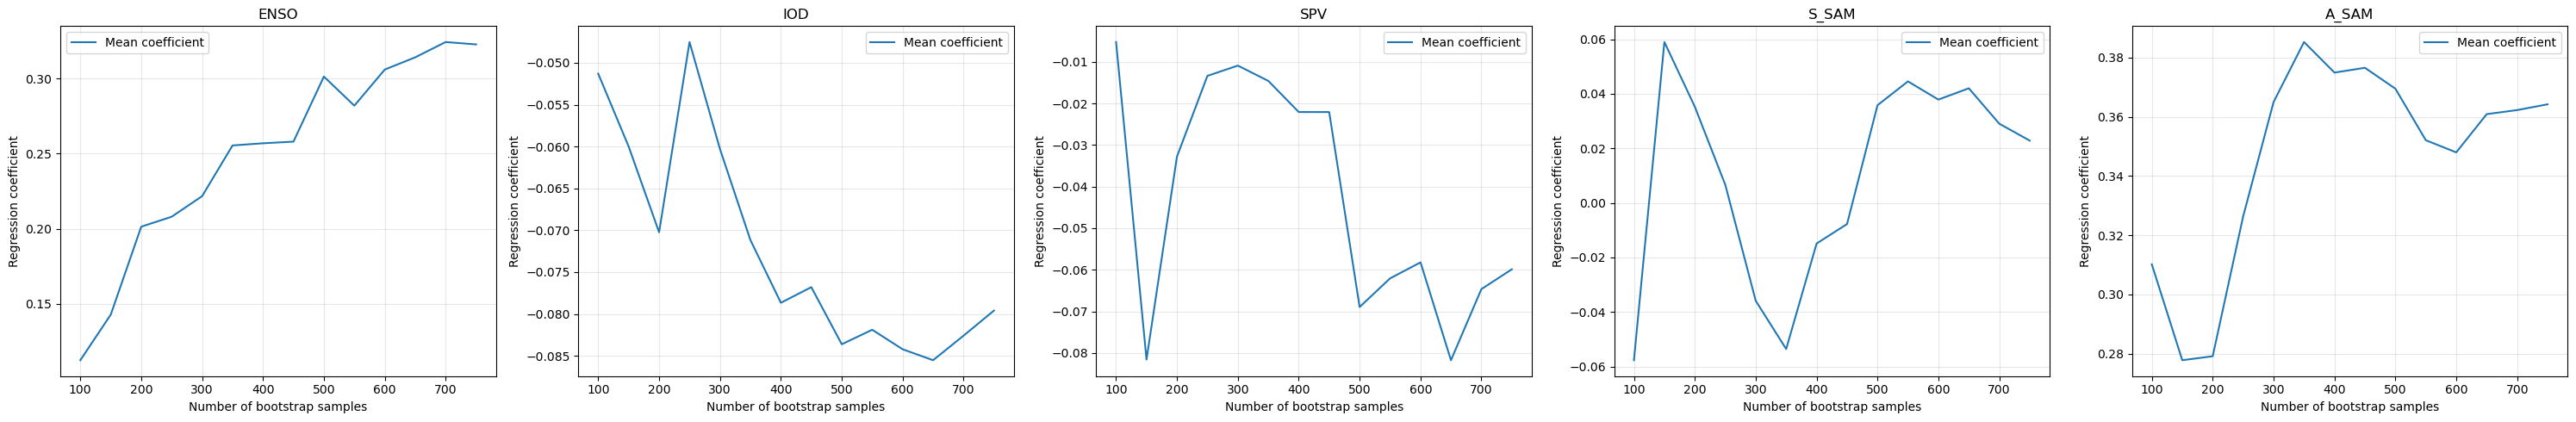

In [86]:
conv_temp_Andes_SON=convergence_boot_plot(np.arange(100,800,50), target_Andes_SON_xr, drivers_SON_xr, 't2m', 
                      drivers_SON, sample_size=73)
#conv_pr_Andes_SON=convergence_boot_plot(np.arange(60,300,20), target_Andes_SON_xr, drivers_SON_xr, 'tp', 
#                      drivers_SON, sample_size=73)